In [2]:
import pandas as pd
import os

DATA_PATH = "../data/features/"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".parquet")]

# Load a few files (not all, to keep it fast)
df_list = [pd.read_parquet(os.path.join(DATA_PATH, f)) for f in files[:5]]

df = pd.concat(df_list, ignore_index=True)

df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration,avg_speed,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day_of_week,congestion_level
0,2016-02-25 17:24:20,2016-02-25 17:27:20,0.70,3.00,14.000000,-73.947250,40.763771,-73.992012,40.735390,17,3,MEDIUM
1,2016-02-25 23:10:50,2016-02-25 23:31:50,5.52,21.00,15.771429,-73.983017,40.750992,-73.988586,40.758839,23,3,MEDIUM
2,2016-02-01 00:00:01,2016-02-01 00:10:52,1.99,10.85,11.004608,-73.992340,40.758202,-73.964355,40.757977,0,0,MEDIUM
3,2016-02-01 00:00:04,2016-02-01 00:05:16,1.50,5.20,17.307692,-73.981453,40.749722,-73.982323,40.763985,0,0,MEDIUM
4,2016-02-01 00:00:05,2016-02-01 00:20:59,5.60,20.90,16.076555,-74.000603,40.729755,-73.951324,40.669834,0,0,MEDIUM


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494449 entries, 0 to 494448
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   tpep_pickup_datetime   494449 non-null  datetime64[us]
 1   tpep_dropoff_datetime  494449 non-null  datetime64[us]
 2   trip_distance          494449 non-null  float64       
 3   trip_duration          494449 non-null  float64       
 4   avg_speed              494449 non-null  float64       
 5   pickup_longitude       494449 non-null  float64       
 6   pickup_latitude        494449 non-null  float64       
 7   dropoff_longitude      494449 non-null  float64       
 8   dropoff_latitude       494449 non-null  float64       
 9   hour                   494449 non-null  int32         
 10  day_of_week            494449 non-null  int32         
 11  congestion_level       494449 non-null  object        
dtypes: datetime64[us](2), float64(7), int32(2), 

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration,avg_speed,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day_of_week
count,494449,494449,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000
mean,2016-02-17 11:54:37.514019,2016-02-17 12:08:13.340113,2.952818,13.597102,11.713453,-72.762110,40.084611,-72.925031,40.173777,14.589644,2.916210
min,2016-02-01 00:00:00,2016-02-01 00:01:53,0.030000,1.016667,1.004184,-80.738029,0.000000,-74.609085,0.000000,0.000000,0.000000
25%,2016-02-05 13:07:31,2016-02-05 13:32:16,1.000000,6.700000,7.804878,-73.991768,40.736877,-73.991653,40.735500,10.000000,0.000000
50%,2016-02-20 16:03:39,2016-02-20 16:17:32,1.700000,10.950000,10.140845,-73.981415,40.753788,-73.980125,40.754169,15.000000,4.000000
75%,2016-02-22 11:18:12,2016-02-22 11:31:56,3.100000,17.466667,13.628571,-73.965538,40.768963,-73.963814,40.768654,19.000000,5.000000
max,2016-02-29 00:00:31,2016-02-29 00:56:41,71.700000,174.933333,99.574468,0.000000,47.633167,0.000000,42.618668,23.000000,6.000000
std,NaN,NaN,3.664845,10.003716,6.149033,9.383336,5.169418,8.748703,4.819753,5.435678,2.540388


In [4]:
df["congestion_level"].value_counts()

congestion_level
HIGH      240104
MEDIUM    231235
LOW        23110
Name: count, dtype: int64

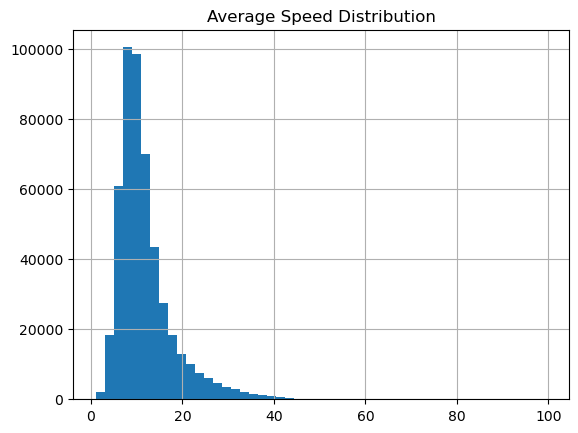

In [5]:
import matplotlib.pyplot as plt

df["avg_speed"].hist(bins=50)
plt.title("Average Speed Distribution")
plt.show()

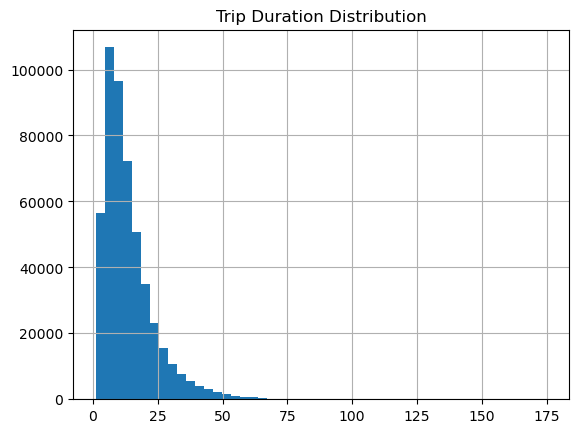

In [6]:
df["trip_duration"].hist(bins=50)
plt.title("Trip Duration Distribution")
plt.show()

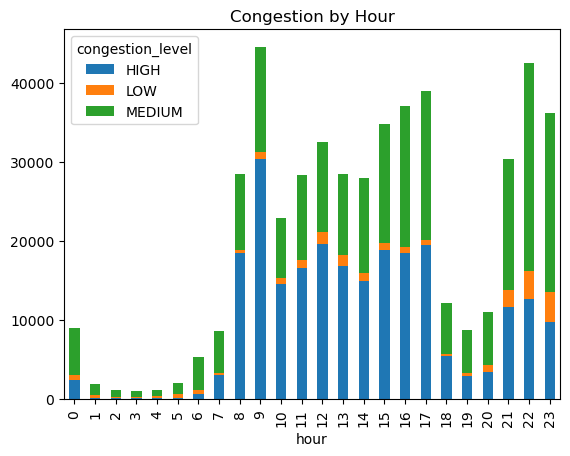

In [7]:
df.groupby("hour")["congestion_level"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.title("Congestion by Hour")
plt.show()

In [8]:
df[["trip_distance", "trip_duration", "avg_speed"]].corr()

,trip_distance,trip_duration,avg_speed
trip_distance,1.000000,0.808374,0.716771
trip_duration,0.808374,1.000000,0.290996
avg_speed,0.716771,0.290996,1.000000


In [16]:
from sklearn.model_selection import train_test_split

X = df[["trip_distance", "hour", "day_of_week"]]
y = df["congestion_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
baseline = LogisticRegression(
    max_iter=500,
    C=1.0,
    solver="lbfgs",
    multi_class="auto")
baseline.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_pred_rf = rf.predict(X_test)

c:\Users\Hmad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["HIGH", "LOW", "MEDIUM"],
            yticklabels=["HIGH", "LOW", "MEDIUM"])

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report_base = classification_report(y_test, y_pred_base, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

f1_scores = pd.DataFrame({
    "Logistic Regression": {
        "HIGH": report_base["HIGH"]["f1-score"],
        "MEDIUM": report_base["MEDIUM"]["f1-score"],
        "LOW": report_base["LOW"]["f1-score"]
    },
    "Random Forest": {
        "HIGH": report_rf["HIGH"]["f1-score"],
        "MEDIUM": report_rf["MEDIUM"]["f1-score"],
        "LOW": report_rf["LOW"]["f1-score"]
    }
})

f1_scores.plot(kind="bar")
plt.title("F1 Score Comparison by Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()